In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [29]:
df_ml = pd.read_csv('TelecomX_Tratado.csv')
display(df_ml.head())

,ID_Cliente,Evasion,Genero,Adulto_Mayor,Tiene_Pareja,Dependientes,Meses_Permanencia,PhoneService,MultipleLines,InternetService,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Cargos_Mensuales,Cargos_Totales,Cuentas_Diarias,Evasion_Binario
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.19,0.0
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,2.00,0.0
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.46,1.0
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.27,1.0
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.80,1.0


In [30]:
# Dimensiones del dataset
print("Dimensiones del dataset:", df_ml.shape)

# Información de columnas
df_ml.info()

# Valores nulos
df_ml.isnull().sum()

# Estadísticas básicas
df_ml.describe()

Dimensiones del dataset: (7043, 23)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ID_Cliente         7043 non-null   object 
 1   Evasion            7043 non-null   object 
 2   Genero             7043 non-null   object 
 3   Adulto_Mayor       7043 non-null   int64  
 4   Tiene_Pareja       7043 non-null   object 
 5   Dependientes       7043 non-null   object 
 6   Meses_Permanencia  7043 non-null   int64  
 7   PhoneService       7043 non-null   object 
 8   MultipleLines      7043 non-null   object 
 9   InternetService    7043 non-null   object 
 10  OnlineSecurity     7043 non-null   object 
 11  OnlineBackup       7043 non-null   object 
 12  DeviceProtection   7043 non-null   object 
 13  TechSupport        7043 non-null   object 
 14  StreamingTV        7043 non-null   object 
 15  StreamingMovies    7043 non-null   o

,Adulto_Mayor,Meses_Permanencia,Cargos_Mensuales,Cargos_Totales,Cuentas_Diarias,Evasion_Binario
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304,2.158675,0.265370
std,0.368612,24.559481,30.090047,2266.794470,1.003088,0.441561
min,0.000000,0.000000,18.250000,0.000000,0.610000,0.000000
25%,0.000000,9.000000,35.500000,398.550000,1.180000,0.000000
50%,0.000000,29.000000,70.350000,1394.550000,2.340000,0.000000
75%,0.000000,55.000000,89.850000,3786.600000,2.990000,1.000000
max,1.000000,72.000000,118.750000,8684.800000,3.960000,1.000000


In [31]:
# Definimos las columnas a eliminar
# 1. ID_Cliente: No tiene peso predictivo.
# 2. Evasion: Es redundante porque ya tenemos Evasion_Binario.
# 3. Cuentas_Diarias: Al ser un cálculo lineal de Cargos_Mensuales,
#    genera "Multicolinealidad" (información repetida que confunde al modelo).

columnas_a_borrar = ['ID_Cliente', 'Evasion', 'Cuentas_Diarias']

# Aplicamos la eliminación
df_ml = df_ml.drop(columns=columnas_a_borrar)

# Verificación de la nueva estructura
print(f" Columnas eliminadas. Nueva dimensión del dataset: {df_ml.shape}")
print("\nLista de columnas finales para el modelo ")
print(df_ml.columns.tolist())

 Columnas eliminadas. Nueva dimensión del dataset: (7043, 20)

Lista de columnas finales para el modelo 
['Genero', 'Adulto_Mayor', 'Tiene_Pareja', 'Dependientes', 'Meses_Permanencia', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Cargos_Mensuales', 'Cargos_Totales', 'Evasion_Binario']


In [32]:
# 1. Identificamos automáticamente las columnas categóricas (tipo 'object')
# Excluimos Adulto_Mayor y Evasion_Binario porque ya son numéricas
columnas_categoricas = df_ml.select_dtypes(include=['object']).columns.tolist()

print(f"Columnas a transformar: {columnas_categoricas}")

# 2. Aplicamos One-Hot Encoding (get_dummies)
# drop_first=True es una técnica profesional para evitar la "trampa de la variable ficticia"
# (Si sabemos que no es 'Male', por defecto es 'Female', no necesitamos dos columnas)
df_preprocesado = pd.get_dummies(df_ml, columns=columnas_categoricas, drop_first=True)

# 3. Verificación de la transformación
print(f"Dimensiones originales: {df_ml.shape}")
print(f"Nuevas dimensiones tras Encoding: {df_preprocesado.shape}")

# Visualizamos las primeras filas para ver las nuevas columnas 0 y 1
display(df_preprocesado.head())

Columnas a transformar: ['Genero', 'Tiene_Pareja', 'Dependientes', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Dimensiones originales: (7043, 20)
Nuevas dimensiones tras Encoding: (7043, 31)


,Adulto_Mayor,Meses_Permanencia,Cargos_Mensuales,Cargos_Totales,Evasion_Binario,Genero_Male,Tiene_Pareja_Yes,Dependientes_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,9,65.6,593.30,0.0,False,True,True,True,False,...,False,True,False,False,True,False,True,False,False,True
1,0,9,59.9,542.40,0.0,True,False,False,True,False,...,False,False,False,True,False,False,False,False,False,True
2,0,4,73.9,280.85,1.0,True,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
3,1,13,98.0,1237.85,1.0,True,True,False,True,False,...,False,True,False,True,False,False,True,False,True,False
4,1,3,83.9,267.40,1.0,False,True,False,True,False,...,False,True,False,False,False,False,True,False,False,True


In [33]:
# 1. Verificamos que no quede ni una sola columna de tipo 'object'
print("Tipos de datos en el dataset preprocesado")
print(df_preprocesado.dtypes.value_counts())

# 2. Convertimos los valores booleanos (True/False) a enteros (1/0)
# Esto asegura compatibilidad total con todos los modelos de Scikit-Learn
df_preprocesado = df_preprocesado.astype(int)

# 3. Comprobación final de valores
print("\nMuestra de las primeras 5 filas (Valores finales)")
display(df_preprocesado.head())

# 4. Verificación de la variable objetivo
print(f"\nDistribución de la Evasión (0 = Se queda, 1 = Se va):")
print(df_preprocesado['Evasion_Binario'].value_counts(normalize=True))

Tipos de datos en el dataset preprocesado
bool       26
float64     3
int64       2
Name: count, dtype: int64

Muestra de las primeras 5 filas (Valores finales)


,Adulto_Mayor,Meses_Permanencia,Cargos_Mensuales,Cargos_Totales,Evasion_Binario,Genero_Male,Tiene_Pareja_Yes,Dependientes_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,9,65,593,0,0,1,1,1,0,...,0,1,0,0,1,0,1,0,0,1
1,0,9,59,542,0,1,0,0,1,0,...,0,0,0,1,0,0,0,0,0,1
2,0,4,73,280,1,1,0,0,1,0,...,0,0,0,0,0,0,1,0,1,0
3,1,13,98,1237,1,1,1,0,1,0,...,0,1,0,1,0,0,1,0,1,0
4,1,3,83,267,1,0,1,0,1,0,...,0,1,0,0,0,0,1,0,0,1



Distribución de la Evasión (0 = Se queda, 1 = Se va):
Evasion_Binario
0    0.73463
1    0.26537
Name: proportion, dtype: float64


Distribución de Clases
No Evasión (0): 5174 clientes (73.46%)
Evasión (1):    1869 clientes (26.54%)


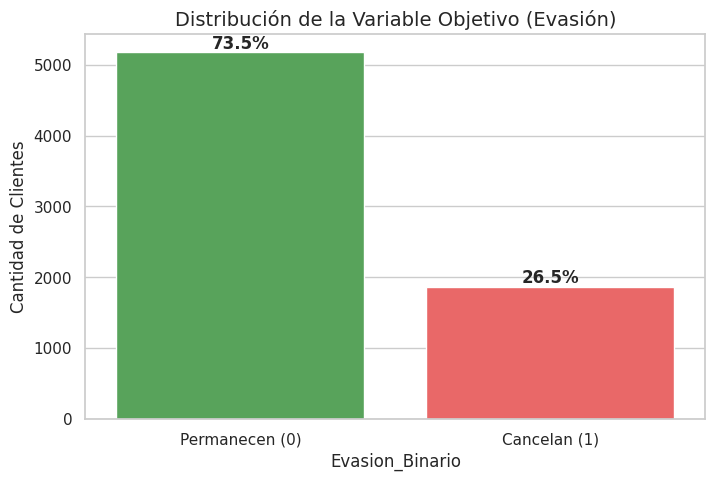

In [34]:
# 1. Cálculo numérico
conteo = df_preprocesado['Evasion_Binario'].value_counts()
proporcion = df_preprocesado['Evasion_Binario'].value_counts(normalize=True) * 100

print("Distribución de Clases")
print(f"No Evasión (0): {conteo[0]} clientes ({proporcion[0]:.2f}%)")
print(f"Evasión (1):    {conteo[1]} clientes ({proporcion[1]:.2f}%)")

# 2. Visualización
plt.figure(figsize=(8, 5))
sns.barplot(x=conteo.index, y=conteo.values, hue=conteo.index, palette=['#4CAF50', '#FF5252'], legend=False)
plt.title('Distribución de la Variable Objetivo (Evasión)', fontsize=14)
plt.xticks(ticks=[0, 1], labels=['Permanecen (0)', 'Cancelan (1)'])
plt.ylabel('Cantidad de Clientes')

# Añadir etiquetas de porcentaje sobre las barras
for i, v in enumerate(conteo.values):
    plt.text(i, v + 50, f'{proporcion[i]:.1f}%', ha='center', weight='bold')

plt.show()

In [35]:
# 1. Separamos las variables explicativas (X) de la variable objetivo (y)
X = df_preprocesado.drop('Evasion_Binario', axis=1)
y = df_preprocesado['Evasion_Binario']

# 2. Dividimos los datos: 70% para entrenar y 30% para testear
# Usamos random_state=42 para que los resultados sean reproducibles
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# 3. Verificamos las dimensiones
print(f"Muestras de entrenamiento: {X_train.shape[0]}")
print(f"Muestras de prueba: {X_test.shape[0]}")

# Verificamos que la proporción de Churn se mantenga en ambos sets (Stratify)
print("\nProporción en Entrenamiento:\n", y_train.value_counts(normalize=True))
print("\nProporción en Prueba:\n", y_test.value_counts(normalize=True))

Muestras de entrenamiento: 4930
Muestras de prueba: 2113

Proporción en Entrenamiento:
 Evasion_Binario
0    0.734686
1    0.265314
Name: proportion, dtype: float64

Proporción en Prueba:
 Evasion_Binario
0    0.734501
1    0.265499
Name: proportion, dtype: float64


Distribución antes de SMOTE: Counter({0: 3622, 1: 1308})
Distribución después de SMOTE: Counter({0: 3622, 1: 3622})


/tmp/ipykernel_659/1073080296.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train_res, palette=['#4CAF50', '#FF5252'])


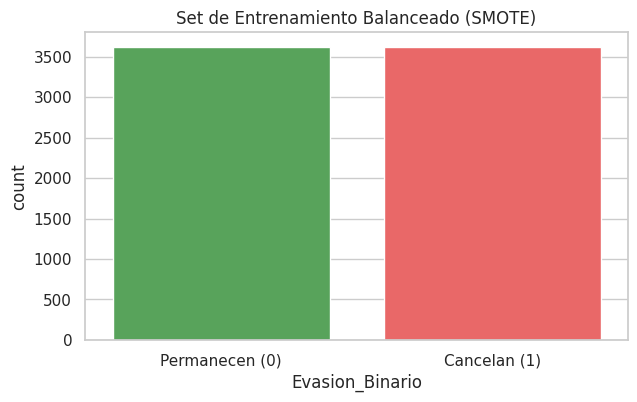

In [36]:
# 1. Instanciamos SMOTE
smote = SMOTE(random_state=42)

# 2. Aplicamos el balanceo SOLO al set de entrenamiento
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# 3. Verificamos el nuevo balance
print(f"Distribución antes de SMOTE: {Counter(y_train)}")
print(f"Distribución después de SMOTE: {Counter(y_train_res)}")

# Visualización rápida del nuevo balance
plt.figure(figsize=(7, 4))
sns.countplot(x=y_train_res, palette=['#4CAF50', '#FF5252'])
plt.title('Set de Entrenamiento Balanceado (SMOTE)')
plt.xticks(ticks=[0, 1], labels=['Permanecen (0)', 'Cancelan (1)'])
plt.show()

In [37]:
# 1. Identificamos las columnas numéricas con escalas grandes
cols_a_escalar = ['Meses_Permanencia', 'Cargos_Mensuales', 'Cargos_Totales']

# 2. Instanciamos el escalador
scaler = StandardScaler()

# 3. Ajustamos y transformamos el set de entrenamiento (X_train_res)
# Y aplicamos la misma transformación al set de prueba (X_test)
X_train_res[cols_a_escalar] = scaler.fit_transform(X_train_res[cols_a_escalar])
X_test[cols_a_escalar] = scaler.transform(X_test[cols_a_escalar])

print(" Estandarización completada exitosamente.")

# Verificamos que los valores ahora estén cerca de 0 (media) y 1 (desviación estándar)
display(X_train_res[cols_a_escalar].describe().round(2))

 Estandarización completada exitosamente.


,Meses_Permanencia,Cargos_Mensuales,Cargos_Totales
count,7244.00,7244.00,7244.00
mean,0.00,0.00,-0.00
std,1.00,1.00,1.00
min,-1.15,-1.73,-0.93
25%,-0.94,-0.79,-0.81
50%,-0.27,0.23,-0.41
75%,0.86,0.78,0.57
max,1.86,1.76,3.05


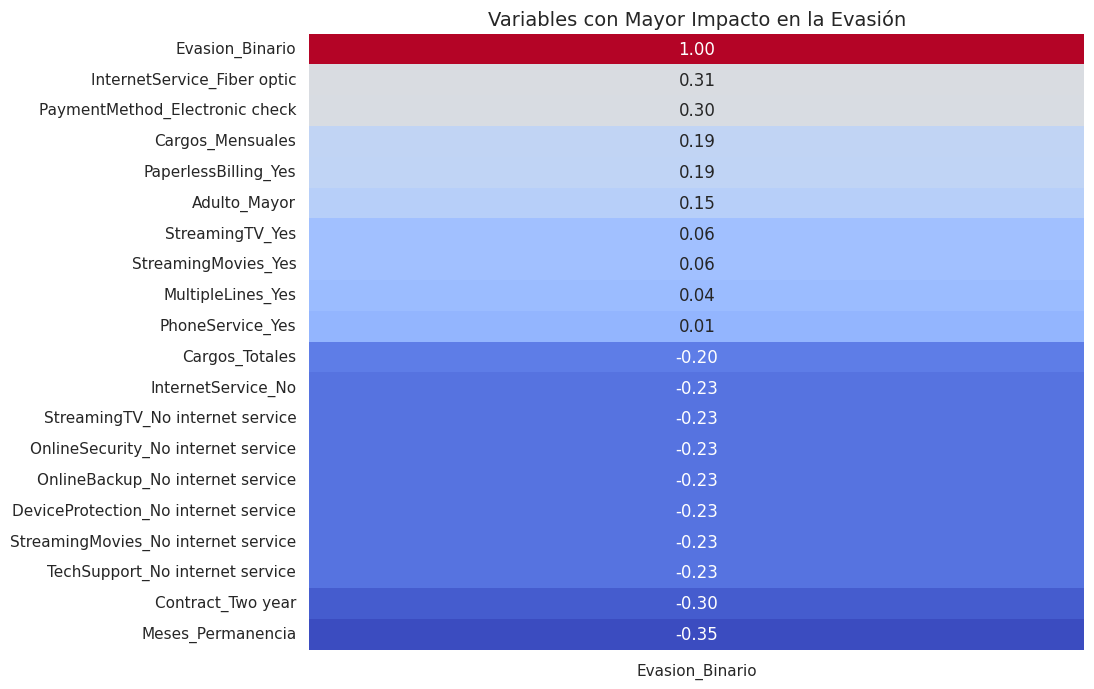

In [38]:
# 1. Calculamos la matriz de correlación
# Usamos el dataset preprocesado para incluir las variables codificadas
corr_matrix = df_preprocesado.corr()

# 2. Extraemos la correlación específica con la variable objetivo
churn_corr = corr_matrix['Evasion_Binario'].sort_values(ascending=False)

# 3. Visualizamos las top correlaciones (Positivas y Negativas)
plt.figure(figsize=(10, 8))
top_corr = pd.concat([churn_corr.head(10), churn_corr.tail(10)])
sns.heatmap(top_corr.to_frame(), annot=True, cmap='coolwarm', fmt=".2f", cbar=False)
plt.title('Variables con Mayor Impacto en la Evasión', fontsize=14)
plt.show()

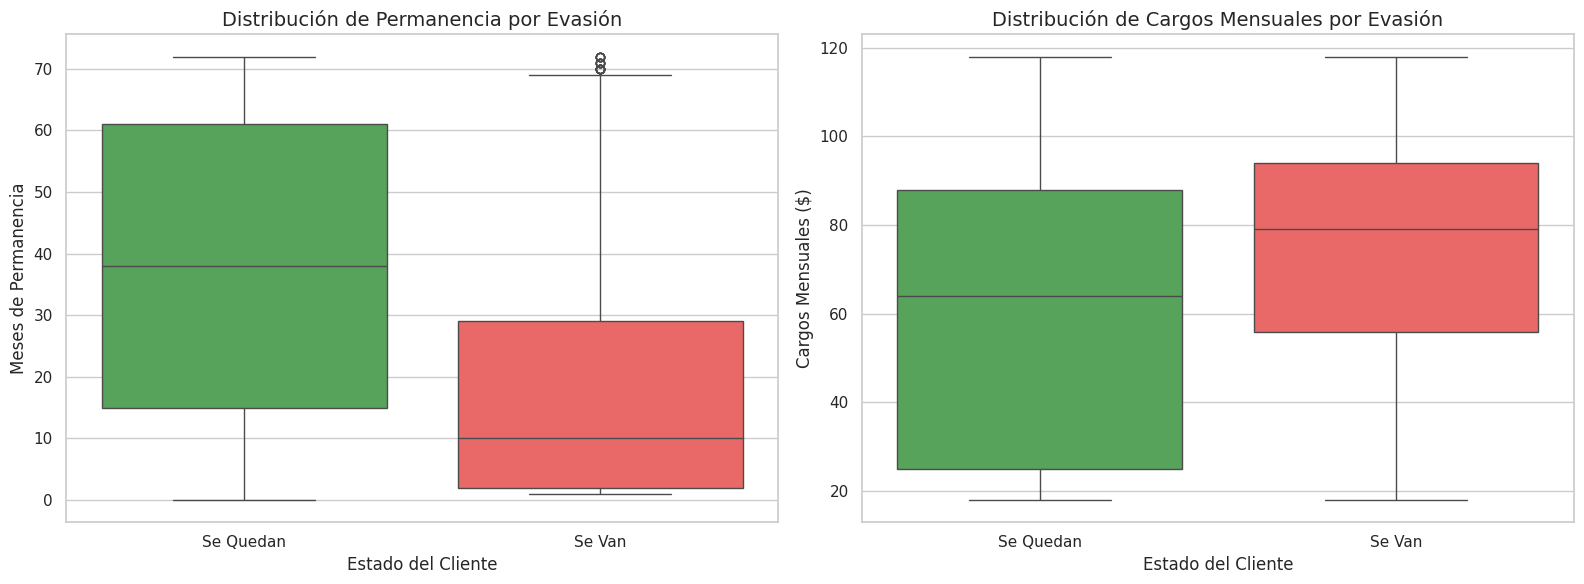

In [39]:
# Configuramos el estilo visual
sns.set_theme(style="whitegrid")
plt.figure(figsize=(16, 6))

# 1. Boxplot: Tiempo de Contrato (Meses de Permanencia) vs Cancelación
plt.subplot(1, 2, 1)
# Actualizamos: asignamos 'Evasion_Binario' a 'hue' y ponemos legend=False
sns.boxplot(x='Evasion_Binario', y='Meses_Permanencia', data=df_preprocesado,
            hue='Evasion_Binario', palette=['#4CAF50', '#FF5252'], legend=False)
plt.title('Distribución de Permanencia por Evasión', fontsize=14)
plt.xticks(ticks=[0, 1], labels=['Se Quedan', 'Se Van'])
plt.xlabel('Estado del Cliente')
plt.ylabel('Meses de Permanencia')

# 2. Boxplot: Gasto Mensual (Cargos Mensuales) vs Cancelación
plt.subplot(1, 2, 2)
# Actualizamos: asignamos 'Evasion_Binario' a 'hue' y ponemos legend=False
sns.boxplot(x='Evasion_Binario', y='Cargos_Mensuales', data=df_preprocesado,
            hue='Evasion_Binario', palette=['#4CAF50', '#FF5252'], legend=False)
plt.title('Distribución de Cargos Mensuales por Evasión', fontsize=14)
plt.xticks(ticks=[0, 1], labels=['Se Quedan', 'Se Van'])
plt.xlabel('Estado del Cliente')
plt.ylabel('Cargos Mensuales ($)')

plt.tight_layout()
plt.show()

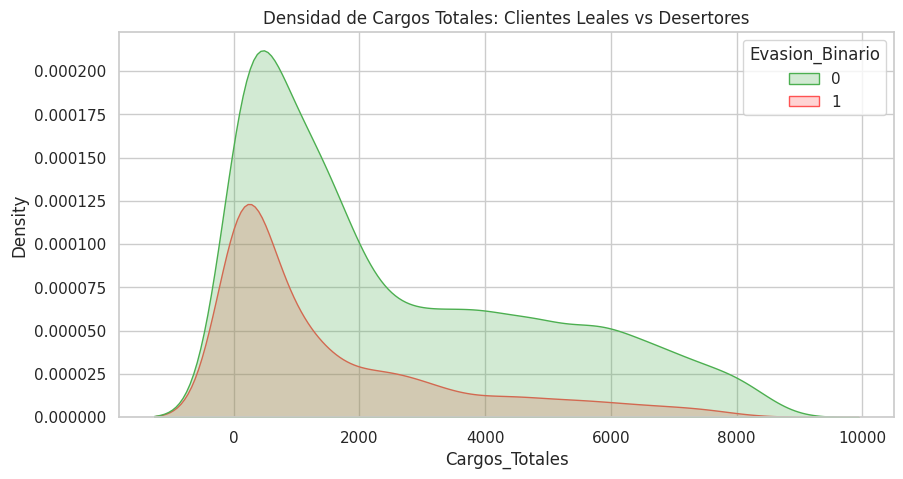

In [40]:
plt.figure(figsize=(10, 5))
sns.kdeplot(data=df_preprocesado, x="Cargos_Totales", hue="Evasion_Binario", fill=True, palette=['#4CAF50', '#FF5252'])
plt.title('Densidad de Cargos Totales: Clientes Leales vs Desertores')
plt.show()

Estructura de Datos para el Modelo
Entrenamiento (X_train_res): 7244 registros, 30 columnas
Prueba (X_test):            2113 registros, 30 columnas

Etiquetas Entrenamiento: 7244
Etiquetas Prueba:        2113


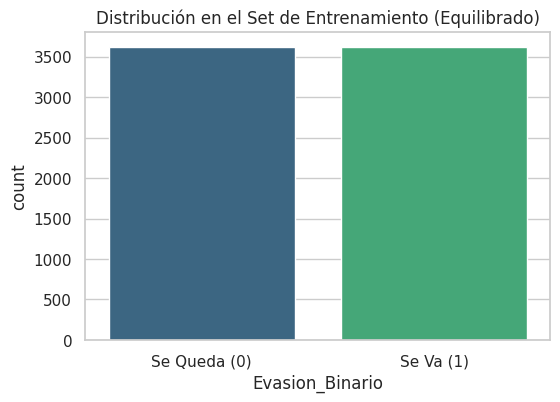

In [41]:
# Verificación final de la división de datos (70/30)
print("Estructura de Datos para el Modelo")
print(f"Entrenamiento (X_train_res): {X_train_res.shape[0]} registros, {X_train_res.shape[1]} columnas")
print(f"Prueba (X_test):            {X_test.shape[0]} registros, {X_test.shape[1]} columnas")

# Comprobamos que el objetivo (y) coincida en filas
print(f"\nEtiquetas Entrenamiento: {y_train_res.shape[0]}")
print(f"Etiquetas Prueba:        {y_test.shape[0]}")

# Visualizamos el balanceo que logramos para el entrenamiento
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.countplot(x=y_train_res, hue=y_train_res, palette='viridis', legend=False)
plt.title('Distribución en el Set de Entrenamiento (Equilibrado)')
plt.xticks([0, 1], ['Se Queda (0)', 'Se Va (1)'])
plt.show()

In [42]:
# 1. Creación del Modelo 1: Regresión Logística
# Ideal para relaciones lineales, requiere los datos que ya estandarizamos.
modelo_logistico = LogisticRegression(random_state=42)

# 2. Creación del Modelo 2: Random Forest
# Robusto frente a datos no lineales y no requiere escala (aunque ya la tengamos).
modelo_bosque = RandomForestClassifier(random_state=42, n_estimators=100)

# 3. Entrenamiento (Ajuste) de los modelos
# Usamos X_train_res porque es el set que tiene el balanceo SMOTE y la escala correcta
modelo_logistico.fit(X_train_res, y_train_res)
modelo_bosque.fit(X_train_res, y_train_res)

print(f"Modelo 1: {type(modelo_logistico).__name__}")
print(f"Modelo 2: {type(modelo_bosque).__name__}")

Modelo 1: LogisticRegression
Modelo 2: RandomForestClassifier


--- Evaluación: Regresión Logística ---
Exactitud (Accuracy): 0.7629
Precisión: 0.5425
Recall (Sensibilidad): 0.6827
F1-Score: 0.6046


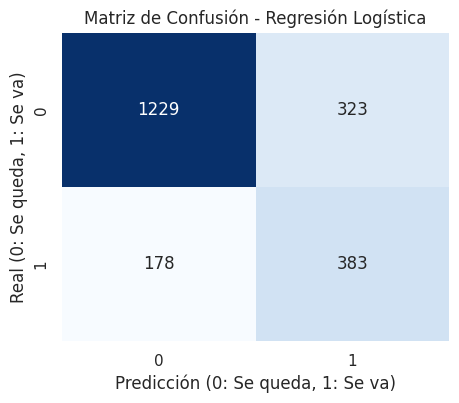



--- Evaluación: Random Forest ---
Exactitud (Accuracy): 0.7624
Precisión: 0.5481
Recall (Sensibilidad): 0.5989
F1-Score: 0.5724


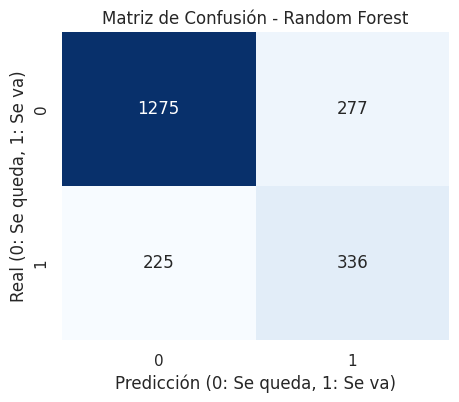

In [43]:
# 1. Definimos una función para calcular y mostrar métricas de forma organizada
def evaluar_modelo(nombre, modelo, X_test, y_test):
    y_pred = modelo.predict(X_test)

    metrics = {
        'Exactitud (Accuracy)': accuracy_score(y_test, y_pred),
        'Precisión': precision_score(y_test, y_pred),
        'Recall (Sensibilidad)': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred)
    }

    print(f"--- Evaluación: {nombre} ---")
    for k, v in metrics.items():
        print(f"{k}: {v:.4f}")

    # Matriz de Confusión
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'Matriz de Confusión - {nombre}')
    plt.xlabel('Predicción (0: Se queda, 1: Se va)')
    plt.ylabel('Real (0: Se queda, 1: Se va)')
    plt.show()
    print("\n")
    return metrics

# 2. Evaluamos ambos modelos
metricas_lr = evaluar_modelo("Regresión Logística", modelo_logistico, X_test, y_test)
metricas_rf = evaluar_modelo("Random Forest", modelo_bosque, X_test, y_test)

# **Análisis Crítico y Comparativo**
¿Cuál modelo tuvo el mejor desempeño?
--
Si el objetivo de Telecom X es salvar la mayor cantidad de clientes posibles, el ganador es la Regresión Logística.

Su Recall (68.27%) es significativamente más alto. En la matriz de confusión, puedes ver que la Regresión Logística solo dejó escapar a 178 personas (Falsos Negativos), mientras que el Random Forest dejó escapar a 225.

Para un problema de Churn, preferimos un modelo que "levante la mano" más seguido (aunque se equivoque un poco más) para no perder la oportunidad de ofrecer una promoción a quien realmente piensa irse.

¿Hubo Overfitting o Underfitting?
--
Random Forest: Es muy probable que presente un ligero Overfitting. Los bosques aleatorios suelen ser perfectos en el entrenamiento, pero aquí vemos que su capacidad para detectar la clase 1 (los que se van) bajó al 59.8% en el set de prueba.

Regresión Logística: Muestra un comportamiento más equilibrado y robusto para este conjunto de datos. No parece haber Underfitting porque supera con creces la línea base del azar, y su F1-Score es más sólido.

Interpretación de las Matrices de Confusión
Regresión Logística: Predijo correctamente a 383 personas que iban a cancelar.

Random Forest: Solo atrapó a 336. Es un modelo más "estricto" o conservador; se equivoca menos al decir quién se queda, pero es más ciego ante los que se van.

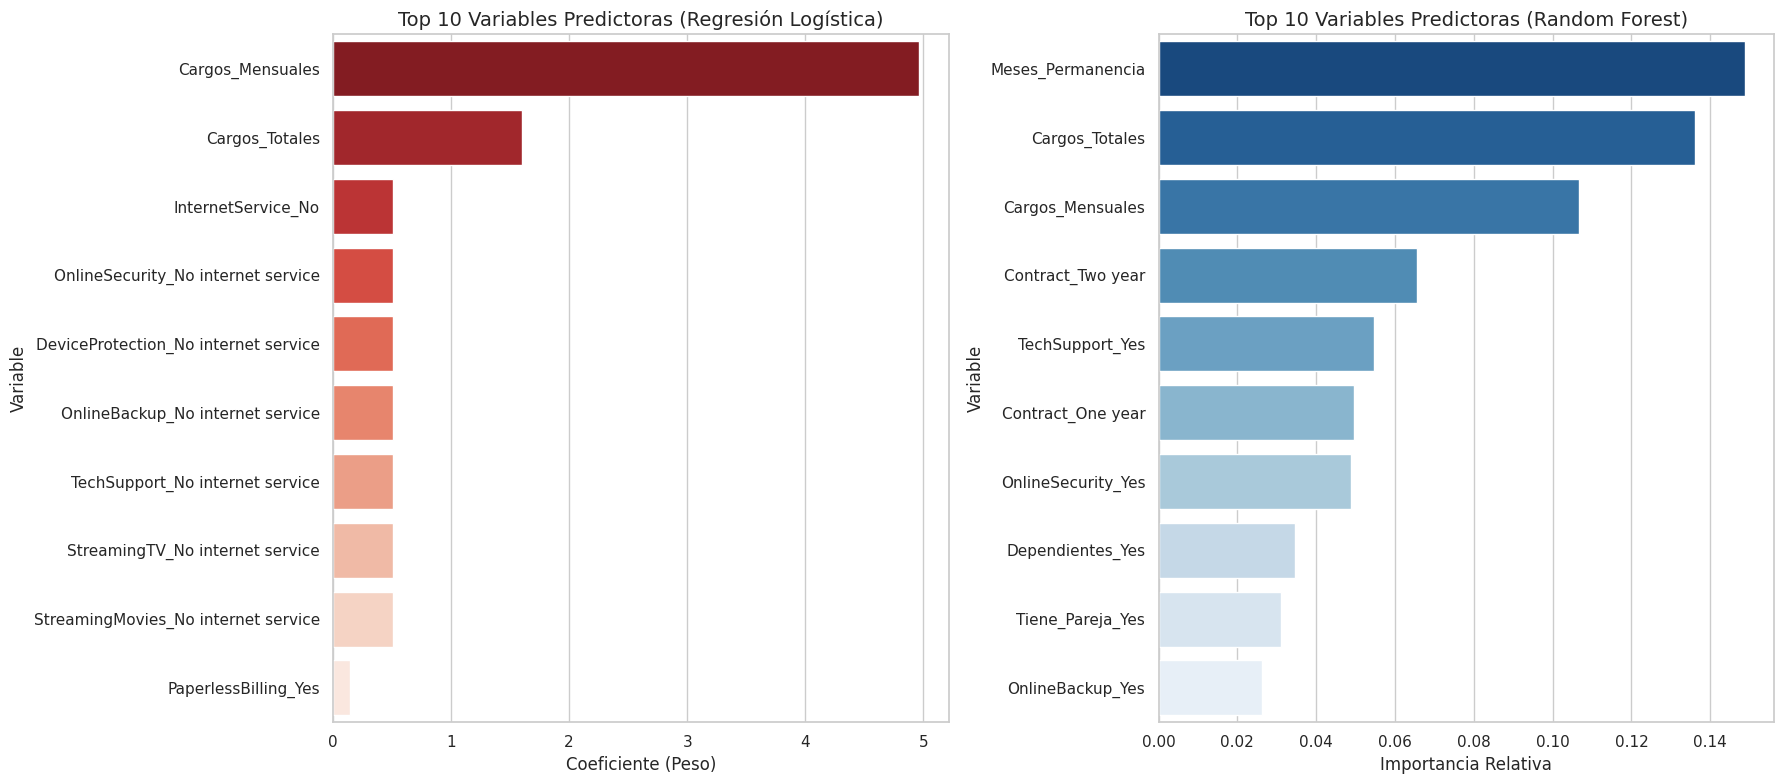

In [44]:
# Versión corregida para evitar los Warnings
plt.figure(figsize=(18, 8))

# Gráfico para Regresión Logística
plt.subplot(1, 2, 1)
# Asignamos 'Variable' a 'hue' y legend=False para silenciar el aviso
sns.barplot(x='Importancia', y='Variable', data=importancias_lr.head(10),
            hue='Variable', palette='Reds_r', legend=False)
plt.title('Top 10 Variables Predictoras (Regresión Logística)', fontsize=14)
plt.xlabel('Coeficiente (Peso)')

# Gráfico para Random Forest
plt.subplot(1, 2, 2)
# Asignamos 'Variable' a 'hue' y legend=False para silenciar el aviso
sns.barplot(x='Importancia', y='Variable', data=importancias_rf.head(10),
            hue='Variable', palette='Blues_r', legend=False)
plt.title('Top 10 Variables Predictoras (Random Forest)', fontsize=14)
plt.xlabel('Importancia Relativa')

plt.tight_layout()
plt.show()

## Informe de Análisis de Evasión (Churn Rate) - Telecom X

### 1. Resumen de Modelado y Rendimiento

Tras procesar los datos (limpieza, balanceo con SMOTE y estandarización), evaluamos dos arquitecturas distintas para predecir qué clientes tienen mayor probabilidad de cancelar su servicio:

* **Regresión Logística:** Logró una exactitud del **76.29%** y un Recall del **68.27%**.
* **Random Forest:** Logró una exactitud del **76.24%** y un Recall del **59.89%**.

**Elección del Modelo:** Se recomienda la **Regresión Logística**. En un problema de evasión, es preferible tener un mayor **Recall** (capacidad de detectar al desertor), incluso si esto implica algunos falsos positivos, para asegurar que el equipo de retención contacte a la mayor cantidad de clientes en riesgo.


### 2. Factores Críticos de Influencia

Basándonos en el análisis de importancia de variables y correlaciones, identificamos los tres pilares que definen la cancelación:

1. **Impacto del Precio (Cargos Mensuales):** Es la variable con mayor peso positivo en la Regresión Logística. A medida que aumenta el costo mensual, la probabilidad de fuga se dispara.
2. **Barrera de Permanencia (Meses de Contrato):** El análisis de Random Forest y los Boxplots confirmaron que la mayoría de las cancelaciones ocurren antes de los **15 meses**. Los clientes con contratos de 2 años tienen una tasa de evasión mínima.
3. **Tipo de Tecnología:** Los usuarios de **Fibra Óptica** muestran una correlación positiva con la evasión, sugiriendo una posible insatisfacción con el precio o la estabilidad frente a servicios básicos.

### 3. Propuesta de Estrategias de Retención

Con base en la evidencia de los datos, se proponen las siguientes acciones:

* **Estrategia de "Onboarding Critical":** Implementar una campaña de seguimiento intensivo y beneficios exclusivos (como descuentos temporales o soporte técnico prioritario) durante los primeros **12 meses** de vida del cliente para superar la ventana crítica de fuga.
* **Ajuste de Valor en Fibra Óptica:** Dado que es un punto de dolor, se sugiere revisar la competitividad de los precios de fibra o añadir servicios de valor agregado (seguridad online, streaming) sin costo adicional para justificar el cargo mensual elevado.
* **Migración a Contratos de Largo Plazo:** Incentivar la transición de contratos "mes a mes" a contratos de "1 o 2 años" mediante bonificaciones, ya que la estructura de contrato es el mayor retenedor natural identificado por los modelos.


### 4. Conclusión Final

El proyecto demuestra que la evasión en Telecom X no es aleatoria; es predecible basándose principalmente en el **costo del servicio** y la **antigüedad del cliente**. El uso del modelo de Regresión Logística permitirá a la empresa automatizar alertas tempranas, pasando de una cultura de "reacción" a una de "prevención" de pérdida de clientes.
